In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# 01 — Rolling Window Setup

This notebook builds the temporal axis and enumerates all valid rolling `(A, B, eval)` window triples for the experiment.

**Input:** `data/processed/` from notebook 00  
**Output:** `data/windows/window_config.json` and diagnostic figures


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

WORKSPACE = Path('/content/drive/MyDrive/Home Insurance MLP')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'
WIN_DIR.mkdir(parents=True, exist_ok=True)

L = 8
S = 2
H = 3
R = 5
K_FRAC = 0.10
PAIR_STRIDE = 4

print(f'Parameters: L={L}, S={S}, H={H}, R={R}, K_FRAC={K_FRAC}, PAIR_STRIDE={PAIR_STRIDE}')


Parameters: L=8, S=2, H=3, R=5, K_FRAC=0.1, PAIR_STRIDE=4


## 1. Load processed data

Load the processed matrices and metadata produced by notebook 00.


In [3]:
X    = pd.read_parquet(PROC_DIR / 'X.parquet')
Y    = np.load(PROC_DIR / 'Y.npy')
meta = pd.read_parquet(PROC_DIR / 'meta.parquet')

meta = meta.reset_index(drop=True)
meta['row_idx'] = meta.index

print(f'X: {X.shape}, Y: {Y.shape}')
print(f'Date range: {meta["quote_date"].min()} → {meta["quote_date"].max()}')


X: (260753, 317), Y: (260753,)
Date range: 2013-01-01 00:00:00 → 2015-05-18 00:00:00


## 2. Define time steps (calendar months)

Each unique calendar month becomes one time step in the chronological sequence used by the rolling-window experiment.


Quotes per calendar month:
month
2013-01-01     7195
2013-02-01     6744
2013-03-01     7493
2013-04-01     8833
2013-05-01     9413
2013-06-01     9798
2013-07-01    11241
2013-08-01    11272
2013-09-01    10245
2013-10-01    10148
2013-11-01     6336
2013-12-01     5740
2014-01-01    11270
2014-02-01     9909
2014-03-01    12008
2014-04-01     9585
2014-05-01     9124
2014-06-01    10091
2014-07-01     9542
2014-08-01     8274
2014-09-01     8067
2014-10-01     7860
2014-11-01     7432
2014-12-01     6945
2015-01-01     9755
2015-02-01     7897
2015-03-01    12241
2015-04-01    10205
2015-05-01     6090


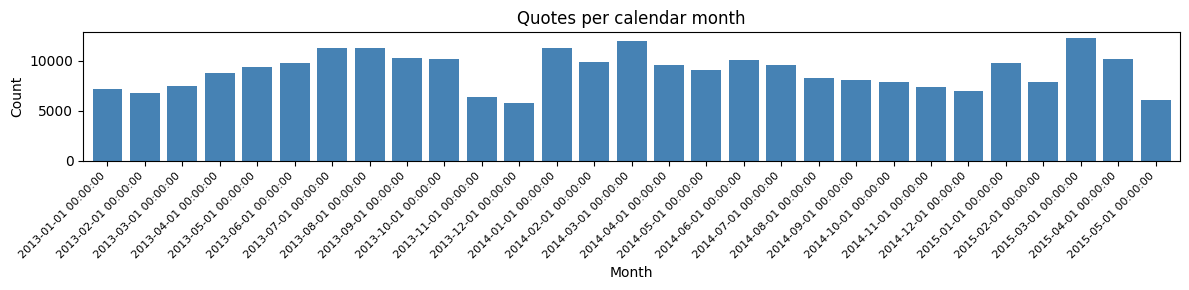

In [4]:
meta['month'] = meta['quote_date'].dt.to_period('M').dt.to_timestamp()

month_counts = meta.groupby('month').size().sort_index()
print('Quotes per calendar month:')
print(month_counts.to_string())

fig, ax = plt.subplots(figsize=(12, 3))
month_counts.plot(ax=ax, kind='bar', color='steelblue', width=0.8)
ax.set_title('Quotes per calendar month')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(WIN_DIR / 'quotes_per_month.png', dpi=120)
plt.show()


In [5]:
time_steps = sorted(month_counts.index.tolist())
K = len(time_steps)
print(f'K = {K} time steps')
for i, ts in enumerate(time_steps):
    n = month_counts[ts]
    print(f'  t_{i+1}: {ts.strftime("%Y-%m")}  ({n:,} quotes)')


K = 29 time steps
  t_1: 2013-01  (7,195 quotes)
  t_2: 2013-02  (6,744 quotes)
  t_3: 2013-03  (7,493 quotes)
  t_4: 2013-04  (8,833 quotes)
  t_5: 2013-05  (9,413 quotes)
  t_6: 2013-06  (9,798 quotes)
  t_7: 2013-07  (11,241 quotes)
  t_8: 2013-08  (11,272 quotes)
  t_9: 2013-09  (10,245 quotes)
  t_10: 2013-10  (10,148 quotes)
  t_11: 2013-11  (6,336 quotes)
  t_12: 2013-12  (5,740 quotes)
  t_13: 2014-01  (11,270 quotes)
  t_14: 2014-02  (9,909 quotes)
  t_15: 2014-03  (12,008 quotes)
  t_16: 2014-04  (9,585 quotes)
  t_17: 2014-05  (9,124 quotes)
  t_18: 2014-06  (10,091 quotes)
  t_19: 2014-07  (9,542 quotes)
  t_20: 2014-08  (8,274 quotes)
  t_21: 2014-09  (8,067 quotes)
  t_22: 2014-10  (7,860 quotes)
  t_23: 2014-11  (7,432 quotes)
  t_24: 2014-12  (6,945 quotes)
  t_25: 2015-01  (9,755 quotes)
  t_26: 2015-02  (7,897 quotes)
  t_27: 2015-03  (12,241 quotes)
  t_28: 2015-04  (10,205 quotes)
  t_29: 2015-05  (6,090 quotes)


In [6]:
MIN_PER_STEP = 50
sparse_months = [ts for ts, n in month_counts.items() if n < MIN_PER_STEP]
if sparse_months:
    print(f'WARNING: {len(sparse_months)} month(s) have < {MIN_PER_STEP} quotes: {sparse_months}')
else:
    print('All months have sufficient quotes.')

month_to_step = {m: i for i, m in enumerate(time_steps)}
meta['step'] = meta['month'].map(month_to_step)


All months have sufficient quotes.


## 3. Enumerate all valid rolling window pairs

For each pair, define:
- training window `A`
- training window `B`
- shared future evaluation slice
- a separate `PAIR_STRIDE` controlling how far one pair is from the next pair


In [7]:
def get_indices(step_set: set) -> list:
    return meta[meta['step'].isin(step_set)]['row_idx'].tolist()


pairs = []

for pair_id, k in enumerate(range(L - 1, K, PAIR_STRIDE)):
    k_b = k + S
    eval_start = k_b + 1
    eval_end   = k_b + H

    if eval_end >= K:
        break

    steps_A    = set(range(k - L + 1, k + 1))
    steps_B    = set(range(k_b - L + 1, k_b + 1))
    steps_eval = set(range(eval_start, eval_end + 1))

    idx_A    = get_indices(steps_A)
    idx_B    = get_indices(steps_B)
    idx_eval = get_indices(steps_eval)

    if len(idx_eval) == 0:
        print(f'Skipping pair k={k}: empty evaluation slice')
        continue

    pairs.append({
        'pair_id':    len(pairs),
        'k':          k,
        'k_b':        k_b,
        'step_label_A':      time_steps[k].strftime('%Y-%m'),
        'step_label_B':      time_steps[k_b].strftime('%Y-%m'),
        'eval_start_label':  time_steps[eval_start].strftime('%Y-%m'),
        'eval_end_label':    time_steps[eval_end].strftime('%Y-%m'),
        'steps_A':    sorted(steps_A),
        'steps_B':    sorted(steps_B),
        'steps_eval': sorted(steps_eval),
        'idx_A':      idx_A,
        'idx_B':      idx_B,
        'idx_eval':   idx_eval,
        'n_train_A':  len(idx_A),
        'n_train_B':  len(idx_B),
        'n_eval':     len(idx_eval),
    })

print(f'\nTotal valid window pairs: {len(pairs)}')



Total valid window pairs: 5


## 4. Leakage checks

The evaluation slice must always be strictly after both training windows.


In [8]:
for p in pairs:
    sA = set(p['steps_A'])
    sB = set(p['steps_B'])
    sE = set(p['steps_eval'])

    assert sA.isdisjoint(sE), f'Leakage: A overlaps eval in pair {p["pair_id"]}'
    assert sB.isdisjoint(sE), f'Leakage: B overlaps eval in pair {p["pair_id"]}'
    assert max(sA) < min(sE), f'Ordering violation in pair {p["pair_id"]}: A not strictly before eval'
    assert max(sB) < min(sE), f'Ordering violation in pair {p["pair_id"]}: B not strictly before eval'

print('All non-overlap checks passed.')


All non-overlap checks passed.


## 5. Save the window configuration

This JSON file is the contract used by notebooks 02–04.


In [9]:
config = {
    'time_unit': 'month',
    'parameters': {
        'L': L,
        'S': S,
        'H': H,
        'R': R,
        'K_FRAC': K_FRAC,
        'PAIR_STRIDE': PAIR_STRIDE,
    },
    'time_steps': [ts.strftime('%Y-%m') for ts in time_steps],
    'pairs': pairs,
}

with open(WIN_DIR / 'window_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'Saved: {WIN_DIR / "window_config.json"}')


Saved: /content/drive/MyDrive/Home Insurance MLP/data/windows/window_config.json


## 6. Visual diagnostics

Summarise train and evaluation sizes across all pairs.


 pair_id   A_end   B_end eval_start eval_end  n_train_A  n_train_B  n_eval
       0 2013-08 2013-10    2013-11  2014-01      71989      78443   23346
       1 2013-12 2014-02    2014-03  2014-05      74193      76161   30717
       2 2014-04 2014-06    2014-07  2014-09      75241      74063   25883
       3 2014-08 2014-10    2014-11  2015-01      79803      74551   24132
       4 2014-12 2015-02    2015-03  2015-05      67335      65772   28536


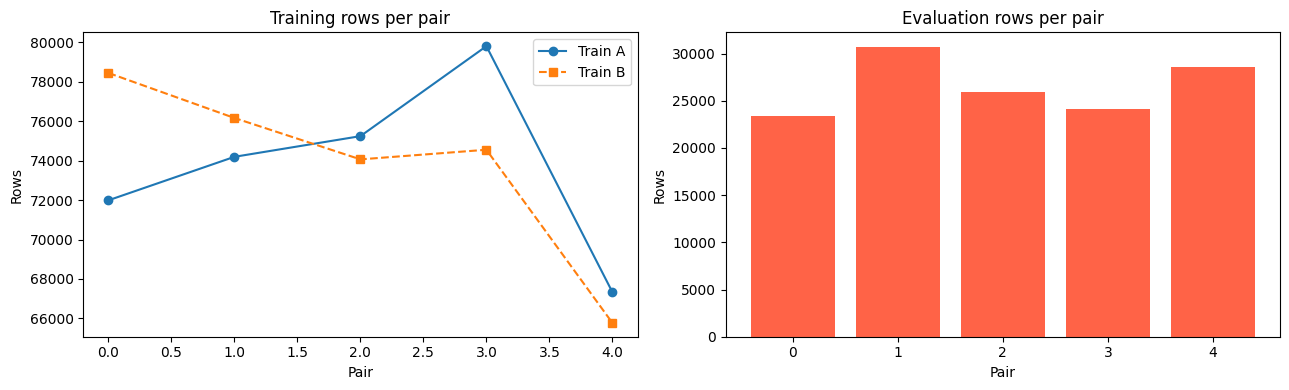

In [10]:
summary = pd.DataFrame([{
    'pair_id': p['pair_id'],
    'A_end': p['step_label_A'],
    'B_end': p['step_label_B'],
    'eval_start': p['eval_start_label'],
    'eval_end': p['eval_end_label'],
    'n_train_A': p['n_train_A'],
    'n_train_B': p['n_train_B'],
    'n_eval': p['n_eval'],
} for p in pairs])

print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(summary['pair_id'], summary['n_train_A'], 'o-', label='Train A')
axes[0].plot(summary['pair_id'], summary['n_train_B'], 's--', label='Train B')
axes[0].set_title('Training rows per pair')
axes[0].set_xlabel('Pair')
axes[0].set_ylabel('Rows')
axes[0].legend()

axes[1].bar(summary['pair_id'], summary['n_eval'], color='tomato')
axes[1].set_title('Evaluation rows per pair')
axes[1].set_xlabel('Pair')
axes[1].set_ylabel('Rows')

plt.tight_layout()
plt.savefig(WIN_DIR / 'pair_size_summary.png', dpi=120)
plt.show()
